In [1]:
import re
import numpy as np
import serial
import time
import matplotlib.pyplot as plt
import ipdb

# --- Configuration ---
SERIAL_PORT = "COM10"  # Replace with your serial port (e.g., "/dev/ttyUSB0" on Linux)
BAUD_RATE = 115200    # Adjust to match your device's baud rate
OUTPUT_FILE = "serial_output.txt"  # File to save the serial stream

# --- Extract histograms from text ---
def extract_histograms(text):
    pattern = r"B (\d+)\s*(.*?)\s*E \d+"
    histograms = []

    for match in re.finditer(pattern, text, re.DOTALL):
        pixel = int(match.group(1))
        histogram_lines = match.group(2).strip().split("\n")

        histogram = []
        for line in histogram_lines:
            values = list(map(int, line.strip().split("_")))
            histogram.extend(values)

        histograms.append(np.array(histogram))

    return histograms

def stream_serial_to_file(port, baud_rate, output_file, timeout=10):
    """
    Stream serial data to a file and stop if "DONE" is encountered or timeout expires.

    Args:
        port (str): Serial port (e.g., "COM3" or "/dev/ttyUSB0").
        baud_rate (int): Baud rate (e.g., 115200).
        output_file (str): Path to the output file.
        timeout (int): Maximum time (seconds) to wait for data before stopping.

    Returns:
        bool: True if "DONE" was encountered, False if timeout expired.
    """
    first = True
    begin_numbers = False
    try:
        with serial.Serial(port, baud_rate, timeout=timeout) as ser, \
             open(output_file, "w") as f:
            print(f"Streaming serial data from {port} to {output_file}...")
            start_time = time.time()

            while True:
                if ser.in_waiting:
                    if(first == True):
                        print("beginning of stream");
                        first = False
                    line = ser.readline().decode("utf-8", errors="ignore").strip()
                    if line:  # Skip empty lines
                        if(line.startswith("B 0")):
                            begin_numbers = True
                            #ipdb.set_trace()
                            
                        if(begin_numbers==False):
                            print(line)
                        else:
                            f.write(line + "\n")
                            f.flush()  # Ensure data is written immediately
                            #print(line)  # Optional: Print to console for debugging

                            # Check for "DONE" (case-insensitive)
                            if "DONE" in line:
                                print("Found 'DONE' in serial output. Stopping stream.")
                                return True

                # Exit after timeout (seconds) if no data is received
                if timeout and (time.time() - start_time) > timeout:
                    print("Timeout reached. Stopping serial stream.")
                    return False

    except serial.SerialException as e:
        print(f"Serial error: {e}")
        return False
    except KeyboardInterrupt:
        print("Stopped by user.")
        return False




def plot_histograms_as_image(histograms, width):
    """
    Plot histograms as an image where the brightness of each pixel
    is determined by the index of the maximum bin in its histogram.

    Args:
        histograms (dict): Dictionary where keys are pixel indices and values are histogram arrays.
        n_rows (int): Number of rows in the image.
        n_cols (int): Number of columns in the image.

    Returns:
        None (displays the image using matplotlib).
    """
    # Initialize an empty image array
    image = np.zeros((width, width), dtype=np.uint8)
    pixel_values = []

    # Fill the image array with the max bin indices
    for pixel, histogram in enumerate(histograms):
        if pixel >= width * width:
            print(f"Warning: Pixel {pixel} exceeds image dimensions ({width}x{width}). Skipping.")
            continue

        # Calculate row and column from pixel index
        row = pixel // width
        col = pixel % width

        # Find the index of the maximum bin value
        max_bin_index = np.argmax(histogram)

        # Normalize the max bin index to 0-255 for grayscale
        # (Assuming histogram bins are in a reasonable range, e.g., 0-35)
        normalized_brightness = int((max_bin_index / len(histogram)) * 255)
        pixel_values.append(normalized_brightness)
        image[row, col] = normalized_brightness

    # Plot the image
    plt.imshow(image, cmap="gray", vmin=min(pixel_values), vmax=max(pixel_values))
    plt.colorbar(label="Brightness (Max Bin Index)")
    plt.title("Image Reconstructed from Histograms")
    plt.show()

    return image    

In [ ]:
# --- Main workflow ---

# Step 1: Stream serial data to file
stream_serial_to_file(SERIAL_PORT, BAUD_RATE, OUTPUT_FILE, timeout=3000000000000)

Streaming serial data from COM10 to serial_output.txt...
beginning of stream
===== Initializing Drivers =====
SCUGIC initialization: Success.
AXI GPIO initialization: Success.
PS7 GPIO initialization: Success.
UART1 initialization: Success.
GPX2 initialization: Success.
DMA initialization: Success.
laser emulator initialization: Success.
Adding UART1 to interrupt system: Success.
Adding Warnings to interrupt system: Success.
Adding Frame Detection to interrupt system: Adding DMA INTR to interrupt system: Success.
Successfully wrote 65536 words to BRAM
> c:\users\marce\appdata\local\temp\ipykernel_24544\3773573967.py(63)stream_serial_to_file()



ipdb>  l


     58                     if line:  # Skip empty lines
     59                         if(line.startswith("B 0")):
     60                             begin_numbers = True
     61                             ipdb.set_trace()
     62 
---> 63                         if(begin_numbers==False):
     64                             print(line)
     65                         else:
     66                             f.write(line + "\n")
     67                             f.flush()  # Ensure data is written immediately
     68                             #print(line)  # Optional: Print to console for debugging



ipdb>  n


> c:\users\marce\appdata\local\temp\ipykernel_24544\3773573967.py(66)stream_serial_to_file()



ipdb>  l


     61                             ipdb.set_trace()
     62 
     63                         if(begin_numbers==False):
     64                             print(line)
     65                         else:
---> 66                             f.write(line + "\n")
     67                             f.flush()  # Ensure data is written immediately
     68                             #print(line)  # Optional: Print to console for debugging
     69 
     70                             # Check for "DONE" (case-insensitive)
     71                             if "DONE" in line:



ipdb>  c


In [20]:
# Step 2: Read the file and extract histograms
with open(OUTPUT_FILE, "r") as f:
    serial_output = f.read()

histograms = extract_histograms(serial_output)

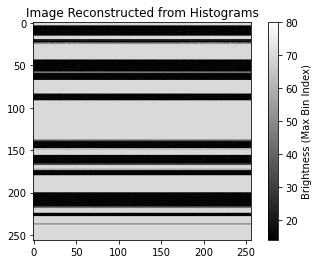

In [21]:
image = plot_histograms_as_image(histograms,256)